<a href="https://colab.research.google.com/github/antonellagambarte/proyecto-final-CEIA/blob/main/PRUEBA_ETAPA_umbral_0_5_0_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [ ]:
ruta_archivo_train = '/content/drive/My Drive/NHANES/dataset_train_imputado.csv'
ruta_archivo_test = '/content/drive/My Drive/NHANES/dataset_test_imputado.csv'


df_train = pd.read_csv(ruta_archivo_train)
df_test = pd.read_csv(ruta_archivo_test)

In [ ]:
df_train.head()

,edad,genero,colesterol_total,hdl,ldl,trigliceridos,proteina_c,bmi,fumo_100_cigarrillos,fumador_actual,...,act_moderada_9.0,prediabetes_glucosa_alterada_2.0,prediabetes_glucosa_alterada_3.0,prediabetes_glucosa_alterada_9.0,colesterol_alto_2.0,colesterol_alto_9.0,riñones_debiles_fallando_2.0,riñones_debiles_fallando_9.0,asma_2.0,asma_9.0
0,0.027815,1,0.635525,-0.409169,110.804858,1.430187,-0.633385,-0.926269,1,-0.450093,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.598832,1,-0.236009,0.044620,100.609504,-0.035063,-0.681892,-1.527568,0,-0.450093,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.869431,1,-0.154793,-0.056492,105.080360,-0.040414,-0.646549,-0.547527,1,2.387436,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.084401,1,0.421306,0.838667,118.001130,-0.366252,-0.041933,-0.024172,0,-0.450093,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,-0.589371,0,0.226934,-0.409169,112.161330,0.702848,0.117120,0.260671,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 59 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   4454 non-null   float64
 1   genero                                 4454 non-null   int64  
 2   colesterol_total                       4454 non-null   float64
 3   hdl                                    4454 non-null   float64
 4   ldl                                    4454 non-null   float64
 5   trigliceridos                          4454 non-null   float64
 6   proteina_c                             4454 non-null   float64
 7   bmi                                    4454 non-null   float64
 8   fumo_100_cigarrillos                   4454 non-null   int64  
 9   fumador_actual                         4454 non-null   float64
 10  act_vigorosa                           4454 non-null   int64  
 11  real

### **Selección de variables para entrenamiento**

Se basó en un enfoque híbrido. Inicialmente, se identificaron 50 variables candidatas a partir de la investigación previa y el estado del arte sobre riesgo cardiovascular. Este conjunto inicial se sometió a un proceso de refinamiento técnico estructurado en tres fases.

En la primera fase, se realizó un análisis de correlación para evaluar la relación entre los distintos predictores. Este paso permitió identificar redundancias y asegurar que cada variable aportara información independiente
al modelo. Asimismo, se consideró la disponibilidad de datos por cada indicador, lo que resultó en el descarte de variables con un volumen excesivo
de valores faltantes.

En la segunda fase, se aplicó un filtro estadístico mediante la técnica de
información mutua a través de la herramienta SelectKBest de Scikit-learn. Este enfoque permitió identificar las variables que aportan mayor
contenido informativo y reducen la incertidumbre sobre el target:

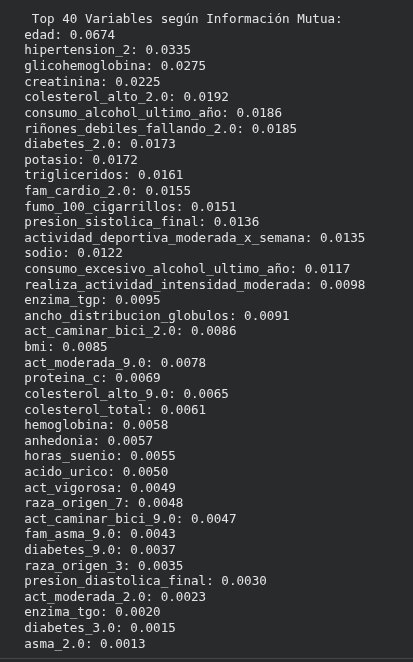

Finalmente, este proceso se completó con una fase de experimentación iterativa. Se entrenaron los modelos de forma repetitiva para monitorear cómo
la inclusión o exclusión de cada predictor afectaba directamente las métricas de desempeño.


(Lo anterior es como está explicado en la memoria)

- LDL se descarta por ser un valor calculado (se obtuvo a partir de un calculo que usa el colesterol total y el HDL)

- glicohemoglobina se descarta por tratarse de un estudio muy específico, no es de rutina. Se pide en casos puntuales.

- Sodio no aportó al momento de entrenar los modelos.

- Enzima tgp y tgo estaban muy correlacionadas (según matriz de correlación obtenida en la etapa de limpieza del dataset). Se probó entrenando con uno u otro, y no aportaron a la mejora de resultados.

- ancho_distribucion_globulos tampoco aporta a la mejora de resultados de los modelos.

In [ ]:
nivel_1_basico = [
    'edad', 'genero', 'fumo_100_cigarrillos', 'actividad_deportiva_moderada_x_semana', 'anhedonia', 'consumo_alcohol_ultimo_año'
]

# ETAPA 2
nivel_2_antecedentes = [
     'bmi', 'presion_sistolica_final', 'presion_diastolica_final', 'fam_cardio_2.0','fam_cardio_9.0', 'fam_diabetes_2.0','fam_diabetes_9.0',
     'fam_asma_2.0', 'fam_asma_9.0', 'hipertension_2','hipertension_9', 'diabetes_2.0', 'diabetes_3.0','diabetes_9.0',
     'riñones_debiles_fallando_2.0','riñones_debiles_fallando_9.0', 'asma_2.0','asma_9.0'
]



# ETAPA 3: Análisis de Laboratorio
nivel_3_laboratorio = [
   'colesterol_total', 'hdl', 'trigliceridos', 'proteina_c', 'hemoglobina', 'creatinina', 'acido_urico', 'potasio'
]

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    make_scorer
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluar_overfitting(
    modelo,
    X_train, y_train,
    X_test, y_test,
    threshold=0.25,
    nombre="Modelo"
):
    # --- VALIDACIÓN CRUZADA ESTRATIFICADA (Para reemplazar los valores de TEST) ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Definimos los scorers personalizados basados en el umbral
    def get_preds(y_true, y_probs):
        return (y_probs >= threshold).astype(int)

    def custom_recall(y_true, y_probs): return recall_score(y_true, get_preds(y_true, y_probs), zero_division=0)
    def custom_precision(y_true, y_probs): return precision_score(y_true, get_preds(y_true, y_probs), zero_division=0)
    def custom_f1(y_true, y_probs): return f1_score(y_true, get_preds(y_true, y_probs), zero_division=0)

    auc_test = np.mean(cross_val_score(modelo, X_train, y_train, cv=skf, scoring='roc_auc'))
    recall_test = np.mean(cross_val_score(modelo, X_train, y_train, cv=skf, scoring=make_scorer(custom_recall, response_method='predict_proba')))
    precision_test = np.mean(cross_val_score(modelo, X_train, y_train, cv=skf, scoring=make_scorer(custom_precision, response_method='predict_proba')))
    f1_test = np.mean(cross_val_score(modelo, X_train, y_train, cv=skf, scoring=make_scorer(custom_f1, response_method='predict_proba')))

    # --- MÉTRICAS DE TRAIN (Ajuste sobre el set completo) ---
    modelo.fit(X_train, y_train)
    prob_train = modelo.predict_proba(X_train)[:, 1]
    pred_train = (prob_train >= threshold).astype(int)

    auc_train = roc_auc_score(y_train, prob_train)
    recall_train = recall_score(y_train, pred_train)
    precision_train = precision_score(y_train, pred_train)
    f1_train = f1_score(y_train, pred_train)

    print(f"\n===== {nombre} ====")
    print("---- TRAIN (Full) ----")
    print(f"AUC: {auc_train:.4f}")
    print(f"Recall: {recall_train:.4f}")
    print(f"Precision: {precision_train:.4f}")
    print(f"F1: {f1_train:.4f}")

    print("\n---- TEST (Promedio CV 5-Folds) ----")
    print(f"AUC: {auc_test:.4f}")
    print(f"Recall: {recall_test:.4f}")
    print(f"Precision: {precision_test:.4f}")
    print(f"F1: {f1_test:.4f}")

    auc_gap = auc_train - auc_test
    recall_gap = recall_train - recall_test
    print(f"\n---- GAP (Train - CV) ----")
    print(f"AUC gap: {auc_gap:.4f}")
    print(f"Recall gap: {recall_gap:.4f}")

    # Matriz de confusión (usamos el set de test original solo para visualización)
    prob_v = modelo.predict_proba(X_test)[:, 1]
    pred_v = (prob_v >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred_v)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues", xticklabels=["Bajo", "Alto"], yticklabels=["Bajo", "Alto"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz Confusión (Hold-out Test) - {nombre}")
    plt.show()

    return {
        "auc_train": auc_train,
        "recall_train": recall_train,
        "precision_train": precision_train,
        "f1_train": f1_train,
        "auc_test": auc_test,
        "recall_test": recall_test,
        "precision_test": precision_test,
        "f1_test": f1_test,
        "auc_gap": auc_gap,
        "recall_gap": recall_gap
    }

In [ ]:
# Inicializamos la lista para almacenar los resultados de los modelos
results = []

In [ ]:
df_results = pd.DataFrame(results)

In [ ]:
df_train_temp = df_train.copy()
df_test_temp = df_test.copy()

In [ ]:
TARGET = "alto_riesgo"

X_train = df_train_temp.drop(columns=[TARGET])
y_train = df_train_temp[TARGET]

X_test = df_test_temp.drop(columns=[TARGET])
y_test = df_test_temp[TARGET]

In [ ]:
nivel_1_cols = [c for c in nivel_1_basico if c in X_train.columns]
nivel_2_cols = nivel_1_cols + [c for c in nivel_2_antecedentes if c in X_train.columns]
nivel_3_cols = nivel_2_cols + [c for c in nivel_3_laboratorio if c in X_train.columns]

# Definición de las etapas
etapas = [nivel_2_cols]
nombres_etapas = ["Etapa 1: Básica + Antecedentes"]

In [ ]:
X_train_etapa_1 = X_train[etapas[0]]
X_test_etapa_1 = X_test[etapas[0]]

In [ ]:
X_train_etapa_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   4454 non-null   float64
 1   genero                                 4454 non-null   int64  
 2   fumo_100_cigarrillos                   4454 non-null   int64  
 3   actividad_deportiva_moderada_x_semana  4454 non-null   float64
 4   anhedonia                              4454 non-null   float64
 5   consumo_alcohol_ultimo_año             4454 non-null   float64
 6   bmi                                    4454 non-null   float64
 7   presion_sistolica_final                4454 non-null   float64
 8   presion_diastolica_final               4454 non-null   float64
 9   fam_cardio_2.0                         4454 non-null   float64
 10  fam_cardio_9.0                         4454 non-null   float64
 11  fam_

### **ENTRENAMIENTOS**



## **Modelos originales seleccionados**

### **ramdom forrest - balanceo propio**


===== Random Forest - BP ====
---- TRAIN (Full) ----
AUC: 0.8846
Recall: 0.8336
Precision: 0.3300
F1: 0.4728

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8454
Recall: 0.7668
Precision: 0.3121
F1: 0.4435

---- GAP (Train - CV) ----
AUC gap: 0.0392
Recall gap: 0.0669


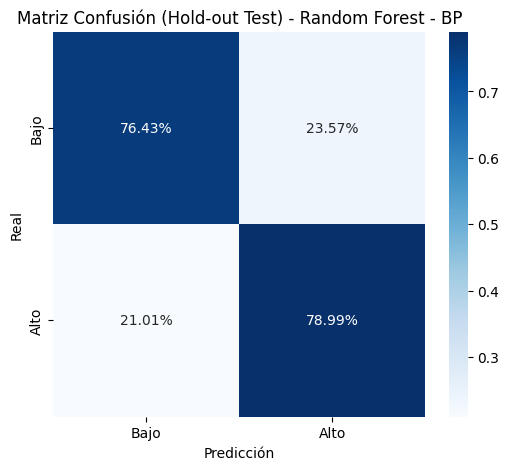

In [ ]:
# Modelo Random Forest con class_weight='balanced'
modelo_rf_balanced_weight = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

modelo_rf_balanced_weight.fit(X_train_etapa_1, y_train)

rf_balanced_weight_metrics = evaluar_overfitting(
    modelo_rf_balanced_weight,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.5,
    nombre="Random Forest - BP"
)

results.append({"Modelo": "Random Forest BP", **rf_balanced_weight_metrics})

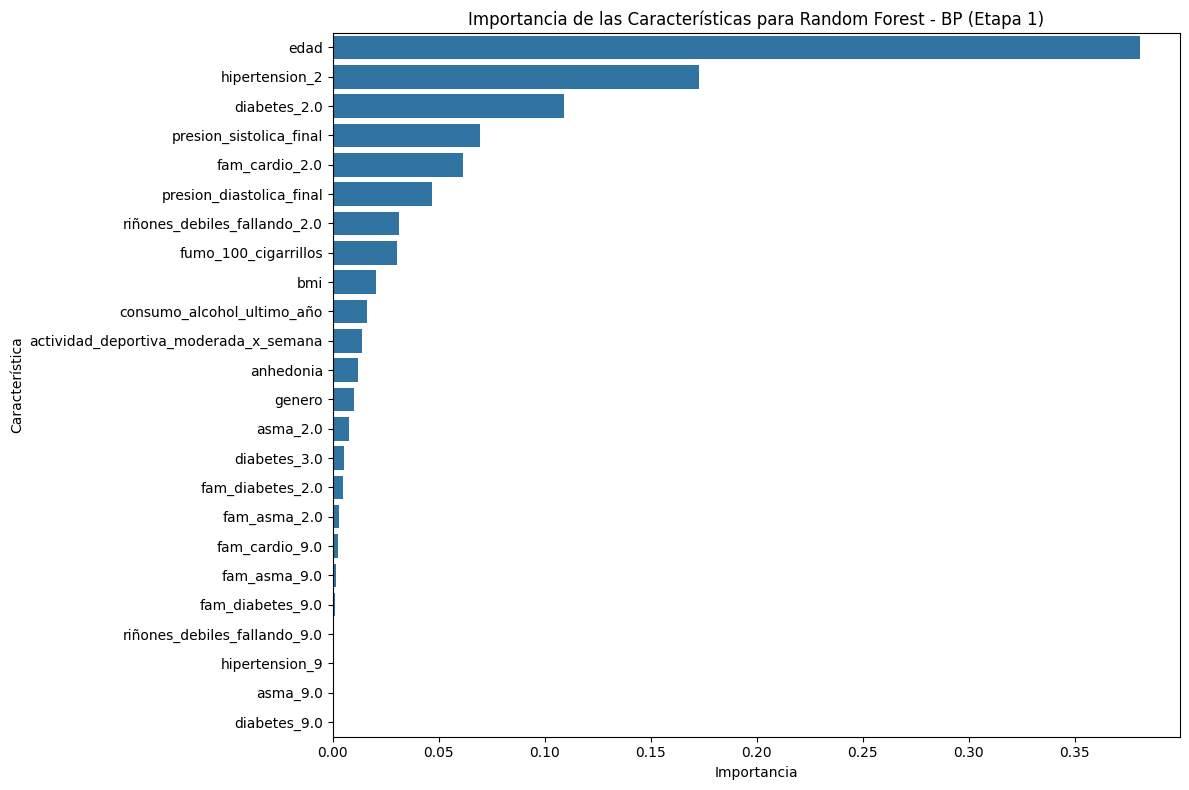

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las importancias de las características del modelo Random Forest optimizado
feature_importances = modelo_rf_balanced_weight.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento
feature_names = X_train_etapa_1.columns

# Crear un DataFrame para visualizar las importancias
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Ordenar por importancia de forma descendente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importancia de las Características para Random Forest - BP (Etapa 1)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

### **xgboost**


===== XGBoost - BP ====
---- TRAIN (Full) ----
AUC: 0.8747
Recall: 0.8517
Precision: 0.3121
F1: 0.4568

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8551
Recall: 0.8174
Precision: 0.3003
F1: 0.4392

---- GAP (Train - CV) ----
AUC gap: 0.0195
Recall gap: 0.0343


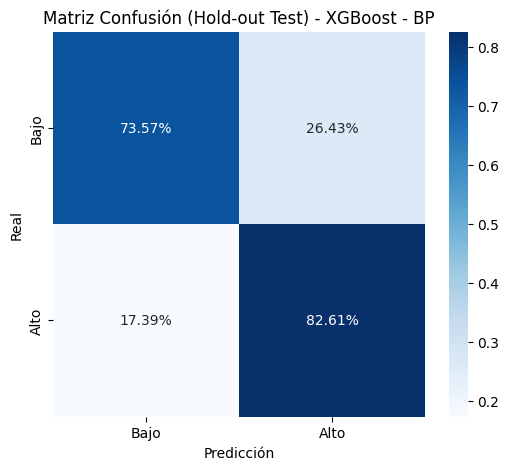

In [ ]:
from xgboost import XGBClassifier

# ratio clases para penalización
ratio = (y_train == 0).sum() / (y_train == 1).sum() #9.55

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_weight=2,
    scale_pos_weight=ratio,
    eval_metric="aucpr",
    random_state=42
)

modelo_xgb.fit(X_train_etapa_1, y_train)

xgb_metrics = evaluar_overfitting(
    modelo_xgb,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.5,
    nombre="XGBoost - BP"
)

results.append({"Modelo": "XGBoost - BP", **xgb_metrics})

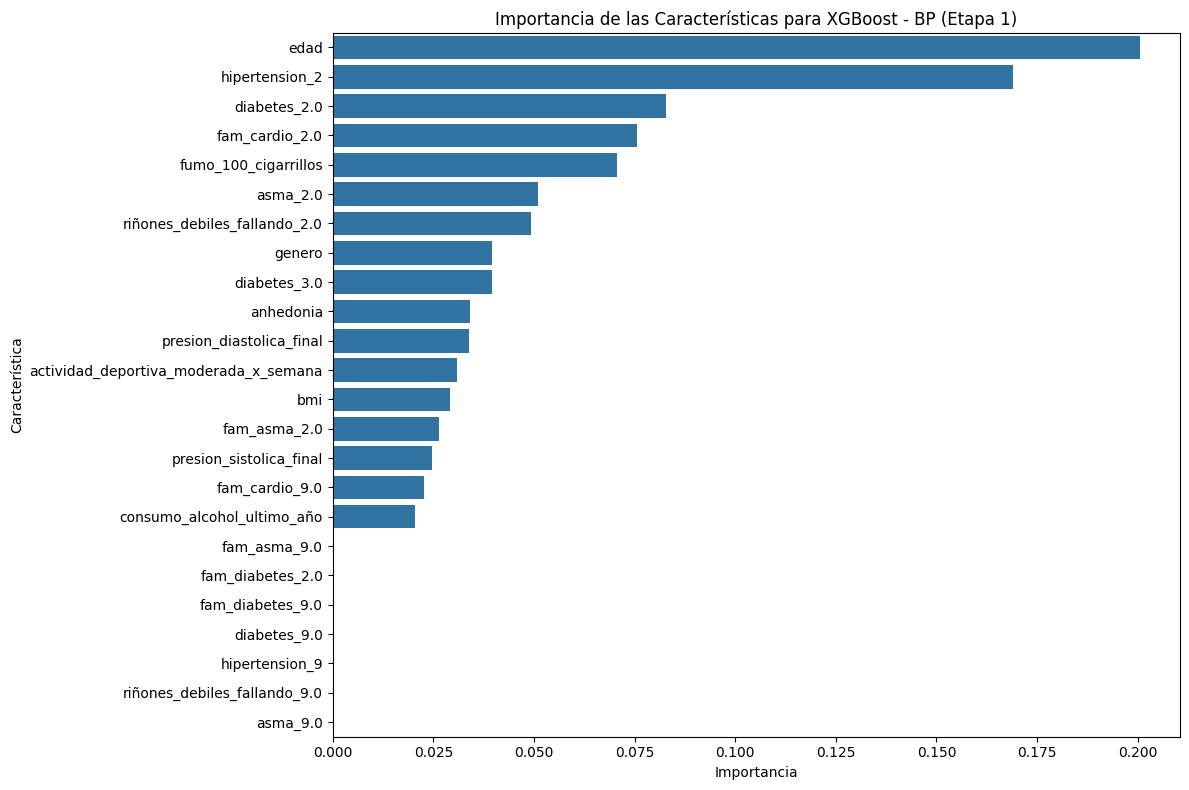

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las importancias de las características del modelo XGBoost
feature_importances_xgb = modelo_xgb.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento
feature_names_xgb = X_train_etapa_1.columns

# Crear un DataFrame para visualizar las importancias
importance_df_xgb = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': feature_importances_xgb
})

# Ordenar por importancia de forma descendente
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb)
plt.title('Importancia de las Características para XGBoost - BP (Etapa 1)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

### **ramdom forrest con undersampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(X_train_etapa_1, y_train)

print("Antes Undersampling:")
print(y_train.value_counts())

print("\nDespués Undersampling:")
print(y_train_under.value_counts())

Antes Undersampling:
alto_riesgo
0    3901
1     553
Name: count, dtype: int64

Después Undersampling:
alto_riesgo
0    691
1    553
Name: count, dtype: int64



===== Random Forest (Undersampling) ====
---- TRAIN (Full) ----
AUC: 0.9022
Recall: 0.7920
Precision: 0.7794
F1: 0.7857

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8506
Recall: 0.7595
Precision: 0.7317
F1: 0.7453

---- GAP (Train - CV) ----
AUC gap: 0.0517
Recall gap: 0.0325


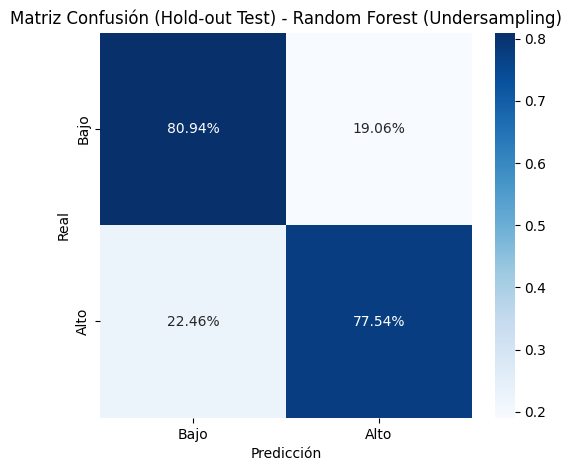

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Modelo Random Forest con Undersampling
modelo_rf_under = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42
)

modelo_rf_under.fit(X_train_under, y_train_under)

rf_under_metrics = evaluar_overfitting(
    modelo_rf_under,
    X_train_under, y_train_under,
    X_test_etapa_1, y_test,
    threshold=0.5,
    nombre="Random Forest (Undersampling)"
)

results.append({"Modelo": "Random Forest (Undersampling)", **rf_under_metrics})

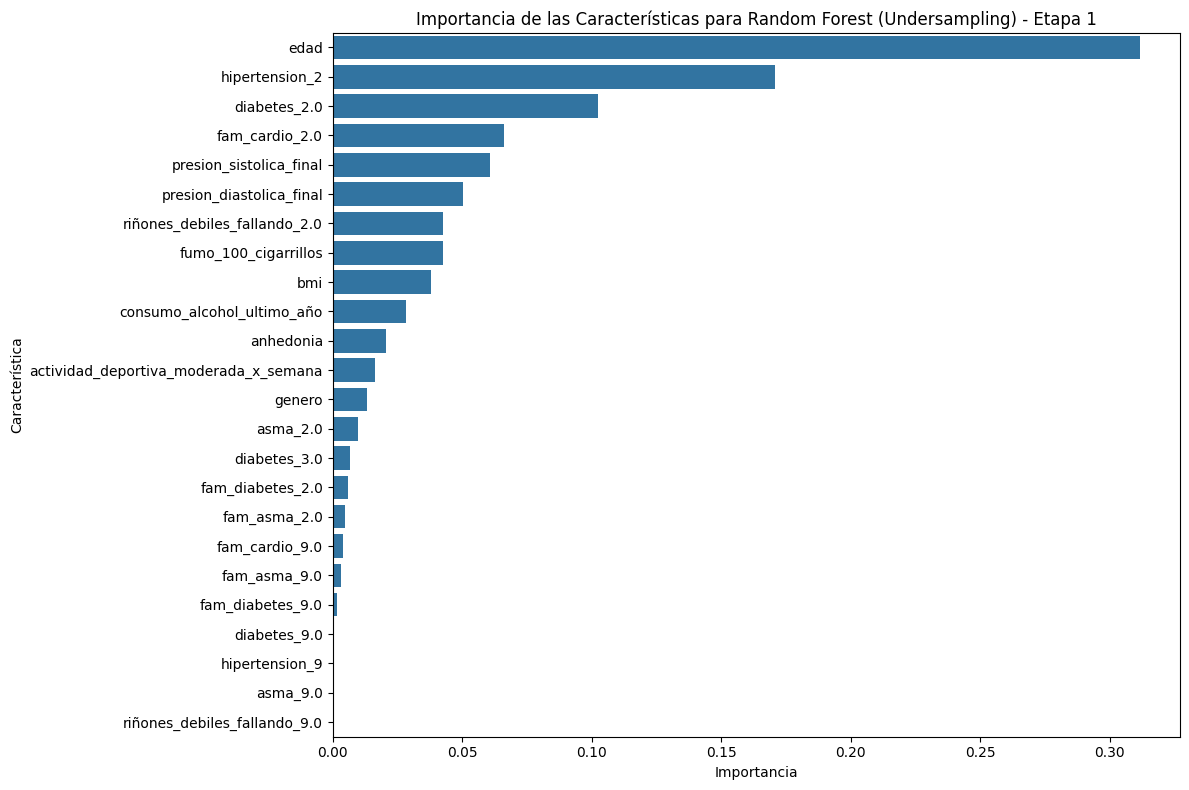

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las importancias de las características del modelo Random Forest con Undersampling
feature_importances_rf_under = modelo_rf_under.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento con undersampling
feature_names_rf_under = X_train_under.columns

# Crear un DataFrame para visualizar las importancias
importance_df_rf_under = pd.DataFrame({
    'Feature': feature_names_rf_under,
    'Importance': feature_importances_rf_under
})

# Ordenar por importancia de forma descendente
importance_df_rf_under = importance_df_rf_under.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf_under)
plt.title('Importancia de las Características para Random Forest (Undersampling) - Etapa 1')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)

print("pruebas con balanceo:")
df_results

pruebas con balanceo:


,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518


## **Búsqueda de hiperparámetros para etapa 1 con Optuna (maximización de recall)**

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.3 MB/s eta 0:00:00


In [ ]:
# # Inicializamos la lista para almacenar los resultados de los modelos
# results = []

# # Creamos un DataFrame vacío para los resultados iniciales
# df_results = pd.DataFrame(results)

### Búsqueda de hiperparámetros con Optuna para Random Forest - BP

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score
import numpy as np


def recall_with_threshold(y_true, y_probs):
    pred_custom = (y_probs >= 0.5).astype(int)
    return recall_score(y_true, pred_custom)

custom_recall_scorer = make_scorer(recall_with_threshold, response_method='predict_proba')

def objective_rf_balanced_weight(trial):
    # Hiperparámetros a optimizar
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train_etapa_1,
        y_train,
        cv=5,
        scoring=custom_recall_scorer,
        n_jobs=-1
    )


    return scores.mean()

# Crear un estudio de Optuna y ejecutar la optimización
study_rf_balanced_weight = optuna.create_study(direction='maximize')
study_rf_balanced_weight.optimize(objective_rf_balanced_weight, n_trials=50)

print(f"Mejores parámetros (CV): {study_rf_balanced_weight.best_params}")
print(f"Mejor recall promedio (CV): {study_rf_balanced_weight.best_value:.4f}")

[I 2026-04-22 03:18:38,030] A new study created in memory with name: no-name-2b07b15b-ff0b-408c-a4fc-1417cad4de29
[I 2026-04-22 03:18:54,975] Trial 0 finished with value: 0.5642751842751843 and parameters: {'max_depth': 10, 'n_estimators': 300, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.5642751842751843.
[I 2026-04-22 03:19:04,707] Trial 1 finished with value: 0.7704013104013103 and parameters: {'max_depth': 5, 'n_estimators': 300, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7704013104013103.
[I 2026-04-22 03:19:10,810] Trial 2 finished with value: 0.783079443079443 and parameters: {'max_depth': 4, 'n_estimators': 250, 'min_samples_split': 12, 'min_samples_leaf': 8}. Best is trial 2 with value: 0.783079443079443.
[I 2026-04-22 03:19:17,631] Trial 3 finished with value: 0.7703685503685505 and parameters: {'max_depth': 4, 'n_estimators': 250, 'min_samples_split': 11, 'min_samples_leaf': 6}. Best is trial 2 with value: 0

Mejores parámetros (CV): {'max_depth': 3, 'n_estimators': 300, 'min_samples_split': 17, 'min_samples_leaf': 1}
Mejor recall promedio (CV): 0.7885


### Evaluación del mejor modelo Random Forest - BP encontrado por Optuna


===== Random Forest - BP Optuna ====
---- TRAIN (Full) ----
AUC: 0.8565
Recall: 0.8137
Precision: 0.2903
F1: 0.4280

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8423
Recall: 0.7939
Precision: 0.2837
F1: 0.4180

---- GAP (Train - CV) ----
AUC gap: 0.0142
Recall gap: 0.0198


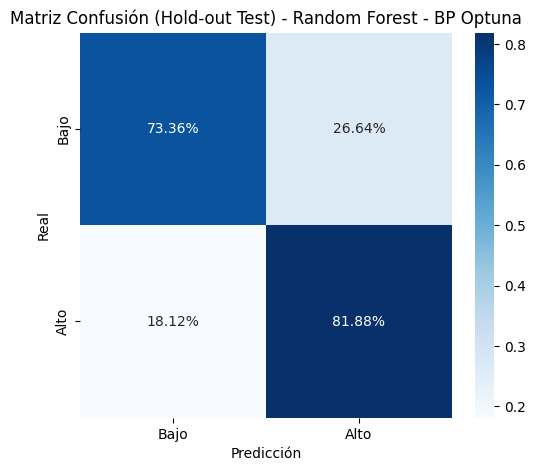

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820


In [ ]:
# Obtener el mejor modelo de Optuna
best_rf_balanced_weight_optuna_model = RandomForestClassifier(
    **study_rf_balanced_weight.best_params,
    random_state=42,
    class_weight='balanced'
)
best_rf_balanced_weight_optuna_model.fit(X_train_etapa_1, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba
best_rf_balanced_weight_optuna_metrics = evaluar_overfitting(
    best_rf_balanced_weight_optuna_model,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.5,
    nombre="Random Forest - BP Optuna"
)

results.append({"Modelo": "Random Forest - BP Optuna", **best_rf_balanced_weight_optuna_metrics})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

### Búsqueda de hiperparámetros con Optuna para XGBoost

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

def recall_with_threshold(y_true, y_probs):
    pred_custom = (y_probs >= 0.5).astype(int)
    return recall_score(y_true, pred_custom)

custom_recall_scorer = make_scorer(recall_with_threshold, response_method='predict_proba')

def objective_xgb(trial):
    # Hiperparámetros a optimizar
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=100)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 0.9)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 0.9)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)

    # Inicializar el modelo XGBoost
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        scale_pos_weight=ratio,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train_etapa_1,
        y_train,
        cv=5,
        scoring=custom_recall_scorer,
        n_jobs=-1
    )

    return scores.mean()

# Crear estudio y optimizar
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"Mejores parámetros con Optuna para XGBoost (CV): {study_xgb.best_params}")
print(f"Mejor recall promedio (CV): {study_xgb.best_value:.4f}")

[I 2026-04-22 03:22:53,816] A new study created in memory with name: no-name-e404de07-b642-444b-8332-b6b474ace530
[I 2026-04-22 03:22:56,857] Trial 0 finished with value: 0.4376412776412776 and parameters: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.07180962953250572, 'subsample': 0.7851009400707004, 'colsample_bytree': 0.8493549140584218, 'min_child_weight': 6}. Best is trial 0 with value: 0.4376412776412776.
[I 2026-04-22 03:22:58,780] Trial 1 finished with value: 0.6184438984438985 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.0464374493582838, 'subsample': 0.5118595183537837, 'colsample_bytree': 0.5127814445698412, 'min_child_weight': 3}. Best is trial 1 with value: 0.6184438984438985.
[I 2026-04-22 03:23:00,568] Trial 2 finished with value: 0.7522522522522521 and parameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.013584994613081571, 'subsample': 0.8203675871196523, 'colsample_bytree': 0.7813660178294479, 'min_child_weight':

Mejores parámetros con Optuna para XGBoost (CV): {'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.01006216193607933, 'subsample': 0.8037223517448808, 'colsample_bytree': 0.8080535436810342, 'min_child_weight': 5}
Mejor recall promedio (CV): 0.8301


### Evaluación del mejor modelo XGBoost encontrado por Optuna

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:23:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:23:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:23:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:23:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


===== XGBoost (Optuna) ====
---- TRAIN (Full) ----
AUC: 0.8709
Recall: 0.8517
Precision: 0.3012
F1: 0.4450

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8534
Recall: 0.8210
Precision: 0.2923
F1: 0.4311

---- GAP (Train - CV) ----
AUC gap: 0.0176
Recall gap: 0.0307


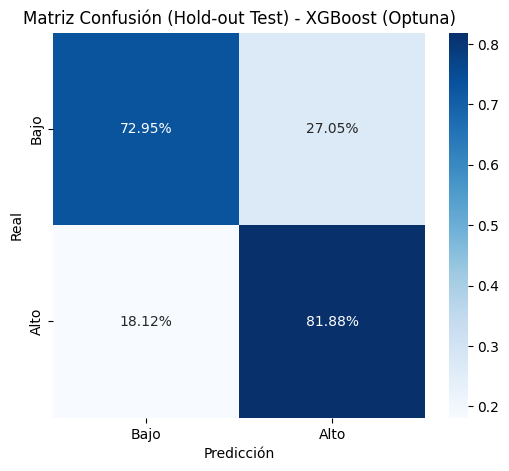

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719


In [ ]:
# Obtener el mejor modelo XGBoost de Optuna
best_xgb_optuna_model = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False
)
best_xgb_optuna_model.fit(X_train_etapa_1, y_train)

best_xgb_optuna_metrics = evaluar_overfitting(
    best_xgb_optuna_model,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.5,
    nombre="XGBoost (Optuna)"
)

results.append({"Modelo": "XGBoost (Optuna)", **best_xgb_optuna_metrics})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

### Búsqueda de hiperparámetros con Optuna para Random Forest (Undersampling)

In [ ]:
import optuna
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

def recall_with_threshold(y_true, y_probs):
    pred_custom = (y_probs >= 0.5).astype(int)
    return recall_score(y_true, pred_custom)

custom_recall_scorer = make_scorer(recall_with_threshold, response_method='predict_proba')

def objective_rf_undersampling(trial):
    # Hiperparámetros del modelo
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Definimos el modelo
    model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ('undersampler', RandomUnderSampler(sampling_strategy=0.8, random_state=42)),
        ('classifier', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train_etapa_1,
        y_train,
        cv=5,
        scoring=custom_recall_scorer,
        n_jobs=-1
    )

    return scores.mean()

# Crear estudio y optimizar
study_rf_undersampling = optuna.create_study(direction='maximize')
study_rf_undersampling.optimize(objective_rf_undersampling, n_trials=50)

print(f"Mejores parámetros con Optuna para RF (Undersampling) con CV: {study_rf_undersampling.best_params}")
print(f"Mejor recall promedio (CV): {study_rf_balanced_weight.best_value:.4f}")

[I 2026-04-22 03:24:06,429] A new study created in memory with name: no-name-596ce98f-de6b-4b2f-8613-719e6aeabeca
[I 2026-04-22 03:24:09,676] Trial 0 finished with value: 0.7197706797706799 and parameters: {'max_depth': 3, 'n_estimators': 300, 'min_samples_split': 14, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.7197706797706799.
[I 2026-04-22 03:24:15,944] Trial 1 finished with value: 0.7143161343161343 and parameters: {'max_depth': 3, 'n_estimators': 250, 'min_samples_split': 9, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.7197706797706799.
[I 2026-04-22 03:24:17,535] Trial 2 finished with value: 0.7034561834561834 and parameters: {'max_depth': 3, 'n_estimators': 100, 'min_samples_split': 15, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.7197706797706799.
[I 2026-04-22 03:24:20,512] Trial 3 finished with value: 0.745045045045045 and parameters: {'max_depth': 4, 'n_estimators': 300, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 3 with value: 0

Mejores parámetros con Optuna para RF (Undersampling) con CV: {'max_depth': 10, 'n_estimators': 50, 'min_samples_split': 19, 'min_samples_leaf': 1}
Mejor recall promedio (CV): 0.7885


### Evaluación del mejor modelo Random Forest (Undersampling) encontrado por Optuna


===== Random Forest (Optuna - Under) ====
---- TRAIN (Full) ----
AUC: 0.9530
Recall: 0.8843
Precision: 0.8330
F1: 0.8579

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8488
Recall: 0.7794
Precision: 0.7308
F1: 0.7541

---- GAP (Train - CV) ----
AUC gap: 0.1042
Recall gap: 0.1048


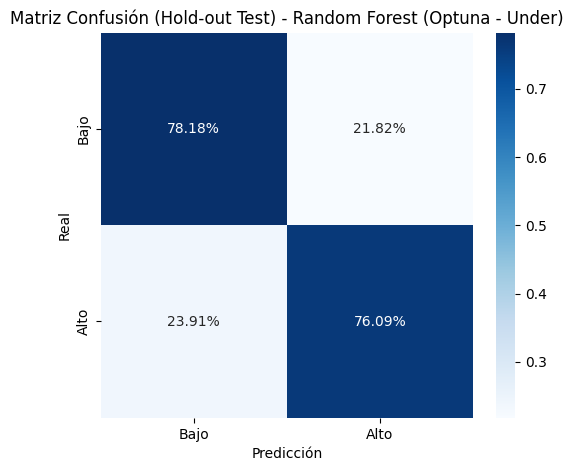


Resultados finales de todos los modelos optimizados con Optuna:


,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841


In [ ]:
# Obtener el mejor modelo de Optuna
best_rf_undersampling_optuna_model = RandomForestClassifier(
    **study_rf_undersampling.best_params,
    random_state=42
)

undersampler_final = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)
X_train_under_final, y_train_under_final = undersampler_final.fit_resample(X_train_etapa_1, y_train)

best_rf_undersampling_optuna_model.fit(X_train_under_final, y_train_under_final)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba (no undersampled)
best_rf_undersampling_optuna_metrics = evaluar_overfitting(
    best_rf_undersampling_optuna_model,
    X_train_under_final, y_train_under_final,
    X_test_etapa_1, y_test,
    threshold=0.5,
    nombre="Random Forest (Optuna - Under)"
)

results.append({"Modelo": "Random Forest (Optuna - Under)", **best_rf_undersampling_optuna_metrics})

# Mostrar los resultados finales actualizados
df_results = pd.DataFrame(results)
print("\nResultados finales de todos los modelos optimizados con Optuna:")
display(df_results)

In [ ]:
display(df_results)

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841


## **Entrenamiento de etapa 2 con hiperparámetros encontrados en etapa 1**

### Preparación de datos para la Etapa 2 (Básicas + Antecedentes + Laboratorio)

In [ ]:
# Definición de las columnas para la Etapa 2
nivel_3_cols = nivel_2_cols + [c for c in nivel_3_laboratorio if c in X_train.columns]

# Actualizar la lista de etapas y nombres de etapas para incluir la Etapa 2
etapas = [nivel_3_cols]
nombres_etapas = ["Etapa 2: Básica + Antecedentes + Laboratorio"]

# Preparar los conjuntos de datos para la Etapa 3
X_train_etapa_3 = X_train[etapas[0]]
X_test_etapa_3 = X_test[etapas[0]]

print(f"Columnas seleccionadas para la Etapa 3: {len(X_train_etapa_3.columns)}")
X_train_etapa_3.info()

Columnas seleccionadas para la Etapa 3: 32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   4454 non-null   float64
 1   genero                                 4454 non-null   int64  
 2   fumo_100_cigarrillos                   4454 non-null   int64  
 3   actividad_deportiva_moderada_x_semana  4454 non-null   float64
 4   anhedonia                              4454 non-null   float64
 5   consumo_alcohol_ultimo_año             4454 non-null   float64
 6   bmi                                    4454 non-null   float64
 7   presion_sistolica_final                4454 non-null   float64
 8   presion_diastolica_final               4454 non-null   float64
 9   fam_cardio_2.0                         4454 non-null   float64
 10  fam_cardio_9.0               

### Evaluación de modelos optimizados con datos de la Etapa 2

#### Re-evaluación: Random Forest - BP Optuna con etapa 2


===== Random Forest - BP Optuna Etapa 2 ====
---- TRAIN (Full) ----
AUC: 0.8637
Recall: 0.8029
Precision: 0.3033
F1: 0.4403

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8441
Recall: 0.7668
Precision: 0.2943
F1: 0.4252

---- GAP (Train - CV) ----
AUC gap: 0.0196
Recall gap: 0.0361


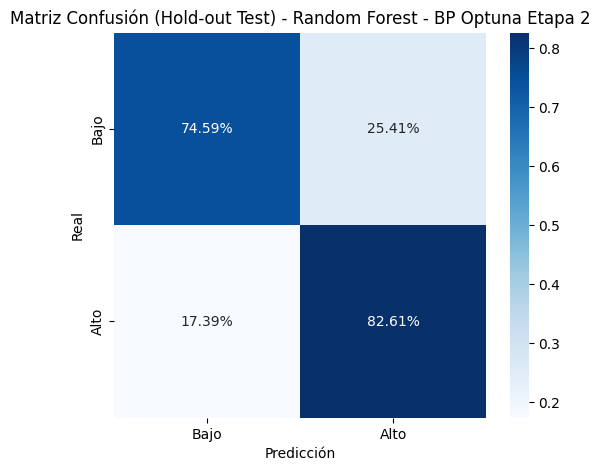

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079


In [ ]:
# Obtener el mejor modelo de Optuna (hiperparámetros ya encontrados)
best_rf_balanced_weight_optuna_model_etapa3 = RandomForestClassifier(
    **study_rf_balanced_weight.best_params,
    random_state=42,
    class_weight='balanced'
)
best_rf_balanced_weight_optuna_model_etapa3.fit(X_train_etapa_3, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba de la Etapa 2
best_rf_balanced_weight_optuna_metrics_etapa3 = evaluar_overfitting(
    best_rf_balanced_weight_optuna_model_etapa3,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=0.5,
    nombre="Random Forest - BP Optuna Etapa 2"
)

results.append({"Modelo": "Random Forest - BP Optuna Etapa 2", **best_rf_balanced_weight_optuna_metrics_etapa3})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

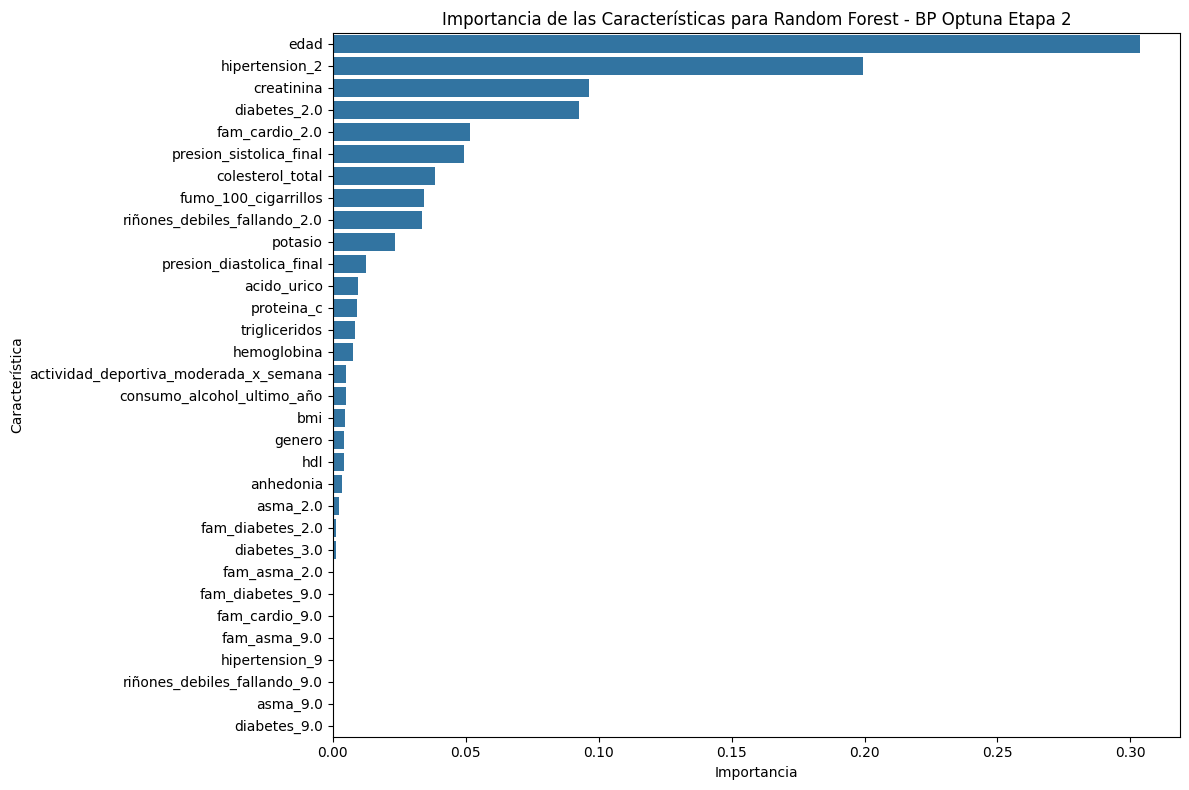

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Re-obtener el mejor modelo de Optuna (hiperparámetros ya encontrados) y entrenarlo nuevamente
best_rf_balanced_weight_optuna_model_etapa3 = RandomForestClassifier(
    **study_rf_balanced_weight.best_params,
    random_state=42,
    class_weight='balanced'
)
best_rf_balanced_weight_optuna_model_etapa3.fit(X_train_etapa_3, y_train)

# Obtener las importancias de las características del modelo
feature_importances_rf_bp_optuna_etapa3 = best_rf_balanced_weight_optuna_model_etapa3.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento de la Etapa 2
feature_names_rf_bp_optuna_etapa3 = X_train_etapa_3.columns

# Crear un DataFrame para visualizar las importancias
importance_df_rf_bp_optuna_etapa3 = pd.DataFrame({
    'Feature': feature_names_rf_bp_optuna_etapa3,
    'Importance': feature_importances_rf_bp_optuna_etapa3
})

# Ordenar por importancia de forma descendente
importance_df_rf_bp_optuna_etapa3 = importance_df_rf_bp_optuna_etapa3.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf_bp_optuna_etapa3)
plt.title('Importancia de las Características para Random Forest - BP Optuna Etapa 2')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

#### Re-evaluación: XGBoost (Optuna) con etapa 2

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:25:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:25:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:25:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:25:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


===== XGBoost (Optuna) Etapa 2 ====
---- TRAIN (Full) ----
AUC: 0.8790
Recall: 0.8590
Precision: 0.3167
F1: 0.4627

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8558
Recall: 0.8138
Precision: 0.3040
F1: 0.4425

---- GAP (Train - CV) ----
AUC gap: 0.0233
Recall gap: 0.0452


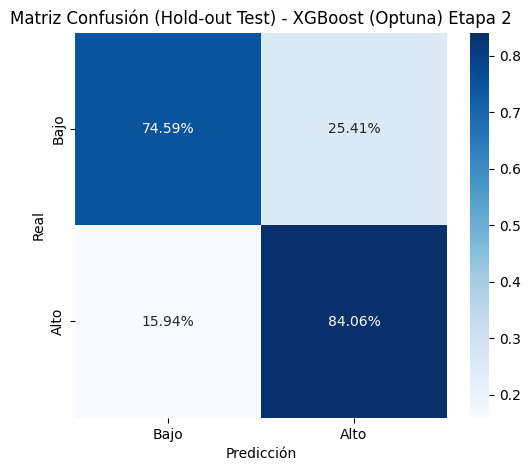

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079
7,XGBoost (Optuna) Etapa 2,0.879030,0.858951,0.316667,0.462737,0.855762,0.813776,0.303959,0.442534,0.023267,0.045176


In [ ]:
# Obtener el mejor modelo XGBoost de Optuna (hiperparámetros ya encontrados)
best_xgb_optuna_model_etapa3 = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False
)
best_xgb_optuna_model_etapa3.fit(X_train_etapa_3, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba de la Etapa 2
best_xgb_optuna_metrics_etapa3 = evaluar_overfitting(
    best_xgb_optuna_model_etapa3,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=0.5,
    nombre="XGBoost (Optuna) Etapa 2"
)

results.append({"Modelo": "XGBoost (Optuna) Etapa 2", **best_xgb_optuna_metrics_etapa3})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:26:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


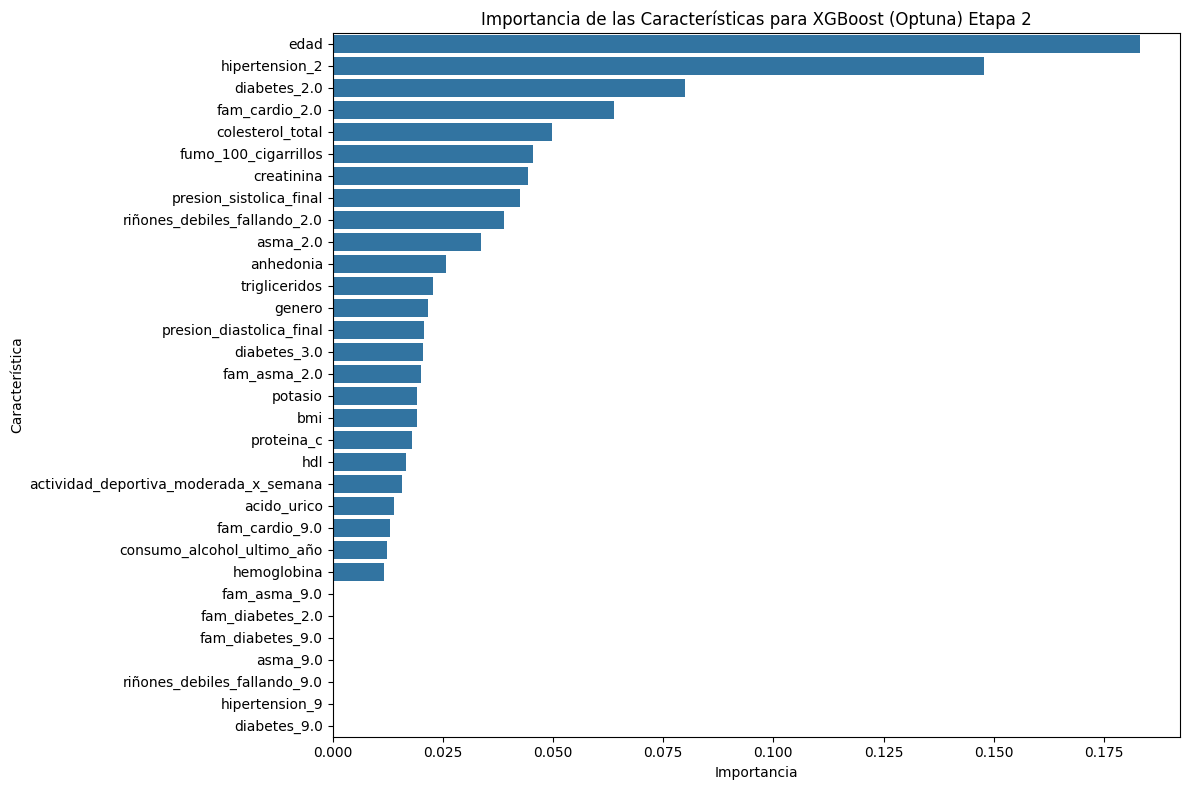

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Re-obtener el mejor modelo XGBoost de Optuna (hiperparámetros ya encontrados) y entrenarlo nuevamente
best_xgb_optuna_model_etapa3_reoptimized = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False
)
best_xgb_optuna_model_etapa3_reoptimized.fit(X_train_etapa_3, y_train)

# Obtener las importancias de las características del modelo XGBoost
feature_importances_xgb_optuna_etapa3_reop = best_xgb_optuna_model_etapa3_reoptimized.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento de la Etapa 2
feature_names_xgb_optuna_etapa3_reop = X_train_etapa_3.columns

# Crear un DataFrame para visualizar las importancias
importance_df_xgb_optuna_etapa3 = pd.DataFrame({
    'Feature': feature_names_xgb_optuna_etapa3_reop,
    'Importance': feature_importances_xgb_optuna_etapa3_reop
})

# Ordenar por importancia de forma descendente
importance_df_xgb_optuna_etapa3 = importance_df_xgb_optuna_etapa3.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb_optuna_etapa3)
plt.title('Importancia de las Características para XGBoost (Optuna) Etapa 2')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

#### Re-evaluación: Random Forest (Optuna - Undersampling) con Etapa 2


===== Random Forest Optuna - Under Etapa 2 ====
---- TRAIN (Full) ----
AUC: 0.9708
Recall: 0.8969
Precision: 0.8810
F1: 0.8889

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8505
Recall: 0.7613
Precision: 0.7285
F1: 0.7443

---- GAP (Train - CV) ----
AUC gap: 0.1203
Recall gap: 0.1356


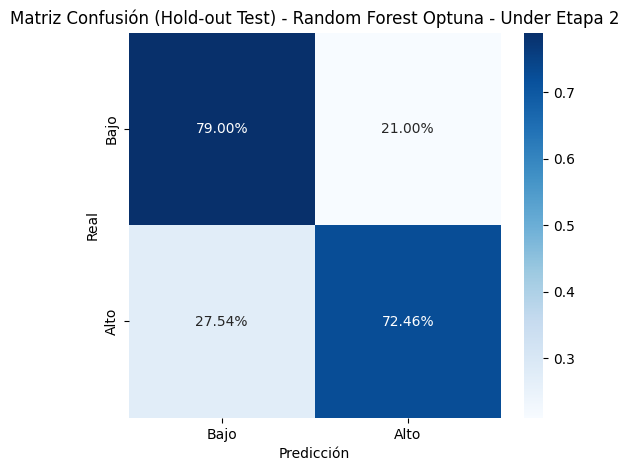

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079
7,XGBoost (Optuna) Etapa 2,0.879030,0.858951,0.316667,0.462737,0.855762,0.813776,0.303959,0.442534,0.023267,0.045176
8,Random Forest Optuna - Under Etapa 2,0.970774,0.896926,0.880995,0.888889,0.850504,0.761310,0.728473,0.744336,0.120270,0.135615


In [ ]:
# Obtener el mejor modelo de Optuna (hiperparámetros ya encontrados)
best_rf_undersampling_optuna_model_etapa3 = RandomForestClassifier(
    **study_rf_undersampling.best_params,
    random_state=42
)

# Aplicar undersampling con los datos de entrenamiento de la Etapa 2 para el modelo final
undersampler_final_etapa3 = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)
X_train_under_final_etapa3, y_train_under_final_etapa3 = undersampler_final_etapa3.fit_resample(X_train_etapa_3, y_train)

best_rf_undersampling_optuna_model_etapa3.fit(X_train_under_final_etapa3, y_train_under_final_etapa3)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba de la Etapa 2 (datos undersampled para train metrics)
best_rf_undersampling_optuna_metrics_etapa3 = evaluar_overfitting(
    best_rf_undersampling_optuna_model_etapa3,
    X_train_under_final_etapa3, y_train_under_final_etapa3,
    X_test_etapa_3, y_test,
    threshold=0.5,
    nombre="Random Forest Optuna - Under Etapa 2"
)

results.append({"Modelo": "Random Forest Optuna - Under Etapa 2", **best_rf_undersampling_optuna_metrics_etapa3})

# Mostrar los resultados finales actualizados
df_results = pd.DataFrame(results)
display(df_results)

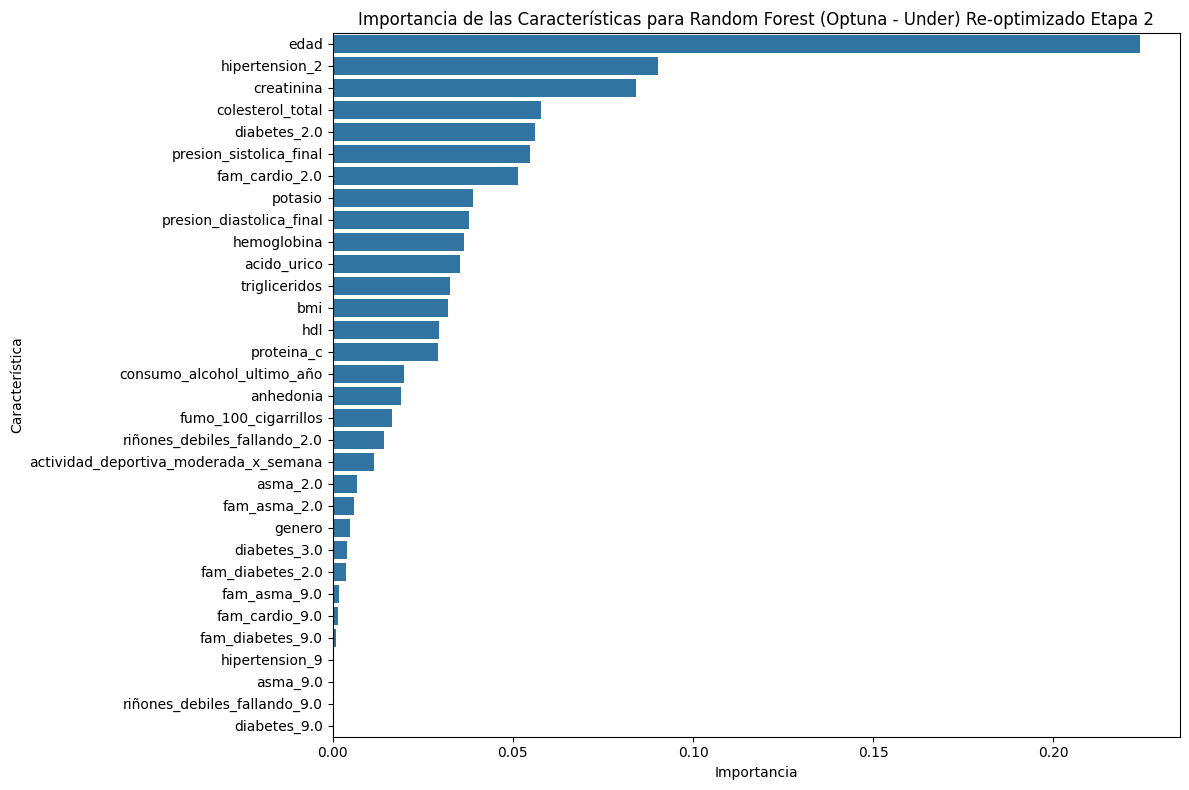

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler

# Re-obtener el mejor modelo de Optuna (hiperparámetros ya encontrados) y entrenarlo nuevamente
best_rf_undersampling_optuna_model_etapa3_reoptimized = RandomForestClassifier(
    **study_rf_undersampling.best_params,
    random_state=42
)

# Re-aplicar undersampling con los datos de entrenamiento de la Etapa 2 para el modelo final
undersampler_final_etapa3_reoptimized = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)
X_train_under_final_etapa3_reoptimized, y_train_under_final_etapa3_reoptimized = undersampler_final_etapa3_reoptimized.fit_resample(X_train_etapa_3, y_train)

best_rf_undersampling_optuna_model_etapa3_reoptimized.fit(X_train_under_final_etapa3_reoptimized, y_train_under_final_etapa3_reoptimized)

# Obtener las importancias de las características del modelo
feature_importances_under_optuna_etapa3_reop = best_rf_undersampling_optuna_model_etapa3_reoptimized.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento con undersampling de la Etapa 2
feature_names_under_optuna_etapa3_reop = X_train_under_final_etapa3_reoptimized.columns

# Crear un DataFrame para visualizar las importancias
importance_df_under_optuna_etapa3 = pd.DataFrame({
    'Feature': feature_names_under_optuna_etapa3_reop,
    'Importance': feature_importances_under_optuna_etapa3_reop
})

# Ordenar por importancia de forma descendente
importance_df_under_optuna_etapa3 = importance_df_under_optuna_etapa3.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_under_optuna_etapa3)
plt.title('Importancia de las Características para Random Forest (Optuna - Under) Re-optimizado Etapa 2')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

In [ ]:
display(df_results)

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079
7,XGBoost (Optuna) Etapa 2,0.879030,0.858951,0.316667,0.462737,0.855762,0.813776,0.303959,0.442534,0.023267,0.045176
8,Random Forest Optuna - Under Etapa 2,0.970774,0.896926,0.880995,0.888889,0.850504,0.761310,0.728473,0.744336,0.120270,0.135615


## **Ahora se van a buscar hiperparámetros nuevos para los datos que incluyen la etapa 2**

### Búsqueda de hiperparámetros con Optuna para Random Forest - BP - Etapa 2

In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

def f1_with_threshold(y_true, y_probs):
    try:
        if y_probs.ndim == 2:
            probs_positiva = y_probs[:, 1]
        else:
            probs_positiva = y_probs

        pred_custom = (probs_positiva >= 0.6).astype(int)
        val_f1 = f1_score(y_true, pred_custom, zero_division=0)
        return val_f1
    except:
        return 0.0

custom_f1_scorer = make_scorer(f1_with_threshold, response_method='predict_proba')

def objective_rf_balanced_weight_etapa3(trial):
    # Hiperparámetros
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        class_weight='balanced',
        n_jobs=1
    )

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    try:
        scores = cross_val_score(
            model,
            X_train_etapa_3,
            y_train,
            cv=cv_strategy,
            scoring=custom_f1_scorer,
            n_jobs=-1
        )

        # Si el promedio es NaN, devolvemos 0 para que Optuna no rompa
        res = np.mean(scores)
        return res if not np.isnan(res) else 0.0

    except Exception:
        return 0.0

study_rf_balanced_weight_etapa3 = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.ERROR)
study_rf_balanced_weight_etapa3.optimize(objective_rf_balanced_weight_etapa3, n_trials=50)

print(f"Mejores parámetros Etapa 3: {study_rf_balanced_weight_etapa3.best_params}")
print(f"Mejor F1-score promedio (CV) Etapa 3: {study_rf_balanced_weight_etapa3.best_value:.4f}")

[I 2026-04-22 03:26:12,559] A new study created in memory with name: no-name-53f1e0e3-aeb5-4817-affb-86ca948740a9


Mejores parámetros Etapa 3: {'max_depth': 4, 'n_estimators': 150, 'min_samples_split': 3, 'min_samples_leaf': 9}
Mejor F1-score promedio (CV) Etapa 3: 0.4731


### Evaluación del mejor modelo Random Forest -BP encontrado por Optuna - Etapa 2


===== Random Forest - BP Optuna Re-optimizado Etapa 2 ====
---- TRAIN (Full) ----
AUC: 0.8773
Recall: 0.6329
Precision: 0.4419
F1: 0.5204

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8472
Recall: 0.5516
Precision: 0.4149
F1: 0.4731

---- GAP (Train - CV) ----
AUC gap: 0.0301
Recall gap: 0.0813


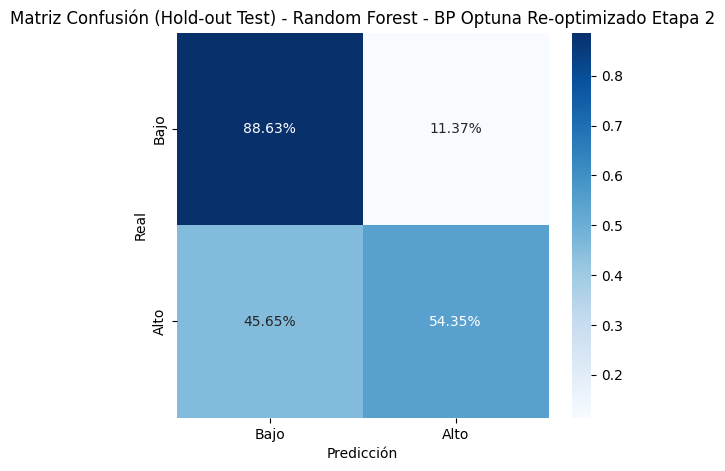

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079
7,XGBoost (Optuna) Etapa 2,0.879030,0.858951,0.316667,0.462737,0.855762,0.813776,0.303959,0.442534,0.023267,0.045176
8,Random Forest Optuna - Under Etapa 2,0.970774,0.896926,0.880995,0.888889,0.850504,0.761310,0.728473,0.744336,0.120270,0.135615
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.877349,0.632911,0.441919,0.520446,0.847210,0.551597,0.414884,0.473144,0.030139,0.081314


In [ ]:
# Obtener el mejor modelo de Optuna para la Etapa 2
best_rf_balanced_weight_optuna_model_etapa3_reoptimized = RandomForestClassifier(
    **study_rf_balanced_weight_etapa3.best_params,
    random_state=42,
    class_weight='balanced'
)
best_rf_balanced_weight_optuna_model_etapa3_reoptimized.fit(X_train_etapa_3, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba de la Etapa 3
best_rf_balanced_weight_optuna_metrics_etapa3_reoptimized = evaluar_overfitting(
    best_rf_balanced_weight_optuna_model_etapa3_reoptimized,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=0.6,
    nombre="Random Forest - BP Optuna Re-optimizado Etapa 2"
)

results.append({"Modelo": "Random Forest - BP Optuna Re-optimizado Etapa 2", **best_rf_balanced_weight_optuna_metrics_etapa3_reoptimized})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

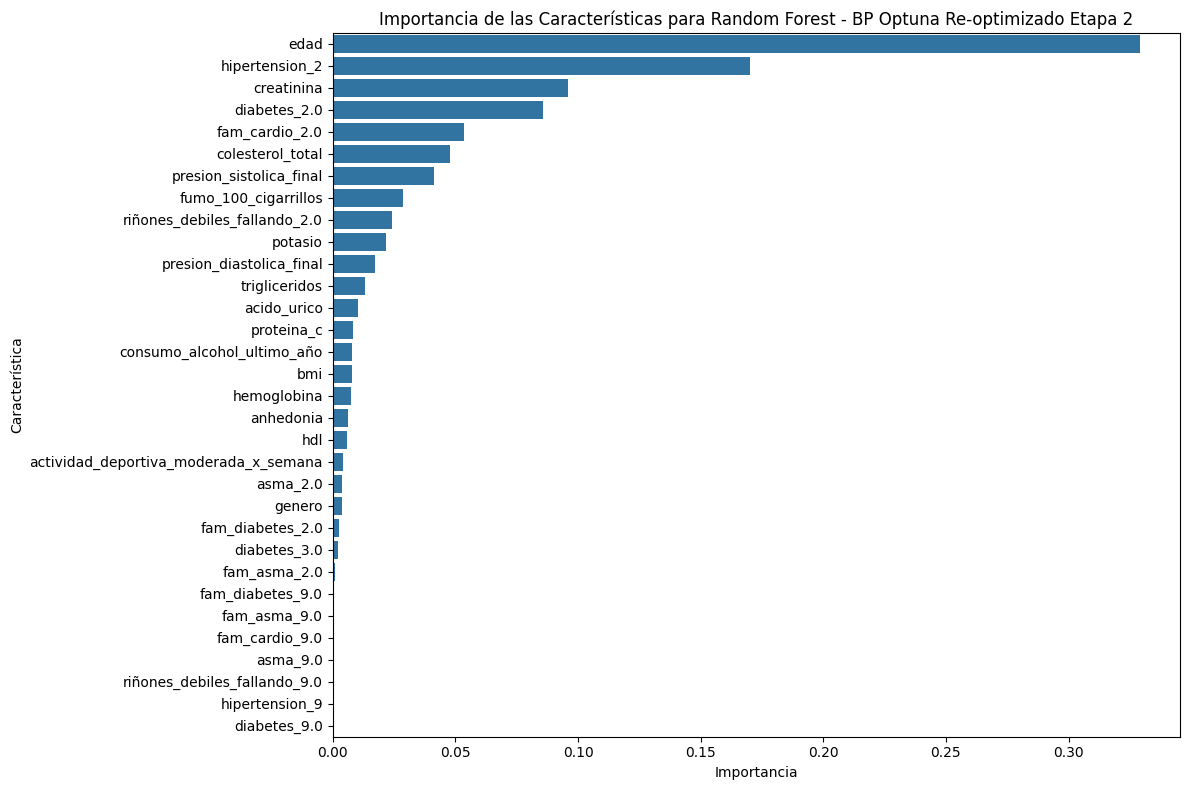

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las importancias de las características del modelo
feature_importances_rf_bp_optuna_etapa3_reoptimized = best_rf_balanced_weight_optuna_model_etapa3_reoptimized.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento de la Etapa 2
feature_names_rf_bp_optuna_etapa3_reoptimized = X_train_etapa_3.columns

# Crear un DataFrame para visualizar las importancias
importance_df_rf_bp_optuna_etapa3_reoptimized = pd.DataFrame({
    'Feature': feature_names_rf_bp_optuna_etapa3_reoptimized,
    'Importance': feature_importances_rf_bp_optuna_etapa3_reoptimized
})

# Ordenar por importancia de forma descendente
importance_df_rf_bp_optuna_etapa3_reoptimized = importance_df_rf_bp_optuna_etapa3_reoptimized.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf_bp_optuna_etapa3_reoptimized)
plt.title('Importancia de las Características para Random Forest - BP Optuna Re-optimizado Etapa 2')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

### Búsqueda de hiperparámetros con Optuna para XGBoost - Etapa 2

In [ ]:
import optuna
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

def f1_with_threshold_xgb(y_true, y_probs):
    try:
        if y_probs.ndim == 2:
            probs_positiva = y_probs[:, 1]
        else:
            probs_positiva = y_probs

        pred_custom = (probs_positiva >= 0.6).astype(int)
        return f1_score(y_true, pred_custom, zero_division=0)
    except Exception:
        return 0.0

custom_f1_scorer = make_scorer(f1_with_threshold_xgb, response_method='predict_proba')

def objective_xgb_etapa3(trial):
    # Hiperparámetros
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=100)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 0.9)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 0.9)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        scale_pos_weight=ratio,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=1
    )

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    try:
        scores = cross_val_score(
            model,
            X_train_etapa_3,
            y_train,
            cv=cv_strategy,
            scoring=custom_f1_scorer,
            n_jobs=-1
        )

        res = np.mean(scores)

        return res if not np.isnan(res) else 0.0

    except Exception as e:
        return 0.0

# Crear estudio y optimizar
study_xgb_etapa3 = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.INFO)
study_xgb_etapa3.optimize(objective_xgb_etapa3, n_trials=50)

print("\n--- Resultados Finales XGBoost Etapa 3 ---")
if len(study_xgb_etapa3.trials) > 0:
    print(f"Mejores parámetros: {study_xgb_etapa3.best_params}")
    print(f"Mejor F1-score promedio (CV): {study_xgb_etapa3.best_value:.4f}")
else:
    print("Error: No se completaron trials. Revisa si 'ratio' está definido.")

[I 2026-04-22 03:29:37,391] Trial 0 finished with value: 0.4531902665183331 and parameters: {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.01037559760639158, 'subsample': 0.5097203797192453, 'colsample_bytree': 0.5535620655574183, 'min_child_weight': 5}. Best is trial 0 with value: 0.4531902665183331.
[I 2026-04-22 03:29:39,191] Trial 1 finished with value: 0.48503394198514566 and parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01628862383646907, 'subsample': 0.8700430507914256, 'colsample_bytree': 0.7371673401770629, 'min_child_weight': 2}. Best is trial 1 with value: 0.48503394198514566.
[I 2026-04-22 03:29:40,404] Trial 2 finished with value: 0.47399019562464434 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.057535985728841124, 'subsample': 0.557049171439205, 'colsample_bytree': 0.8876177685210145, 'min_child_weight': 6}. Best is trial 1 with value: 0.48503394198514566.
[I 2026-04-22 03:29:45,361] Trial 3 finished with value: 


--- Resultados Finales XGBoost Etapa 3 ---
Mejores parámetros: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.027253670806361114, 'subsample': 0.7688927262926967, 'colsample_bytree': 0.6872051922267621, 'min_child_weight': 10}
Mejor F1-score promedio (CV): 0.4972


### Evaluación del mejor modelo XGBoost encontrado por Optuna - Etapa 2

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


===== XGBoost (Optuna) Re-optimizado Etapa 2 ====
---- TRAIN (Full) ----
AUC: 0.9286
Recall: 0.8156
Precision: 0.4659
F1: 0.5930

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8542
Recall: 0.6583
Precision: 0.3999
F1: 0.4972

---- GAP (Train - CV) ----
AUC gap: 0.0744
Recall gap: 0.1573


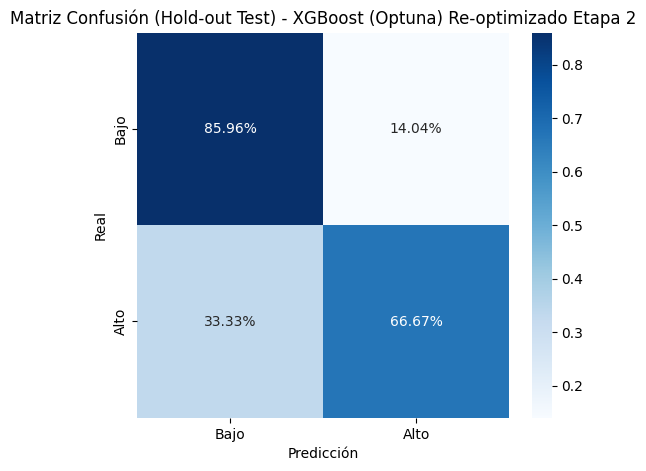

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079
7,XGBoost (Optuna) Etapa 2,0.879030,0.858951,0.316667,0.462737,0.855762,0.813776,0.303959,0.442534,0.023267,0.045176
8,Random Forest Optuna - Under Etapa 2,0.970774,0.896926,0.880995,0.888889,0.850504,0.761310,0.728473,0.744336,0.120270,0.135615
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.877349,0.632911,0.441919,0.520446,0.847210,0.551597,0.414884,0.473144,0.030139,0.081314


In [ ]:
best_xgb_optuna_model_etapa3_reoptimized = XGBClassifier(
    **study_xgb_etapa3.best_params,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False
)
best_xgb_optuna_model_etapa3_reoptimized.fit(X_train_etapa_3, y_train)

best_xgb_optuna_metrics_etapa3_reoptimized = evaluar_overfitting(
    best_xgb_optuna_model_etapa3_reoptimized,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=0.6,
    nombre="XGBoost (Optuna) Re-optimizado Etapa 2"
)

results.append({"Modelo": "XGBoost (Optuna) Re-optimizado Etapa 2", **best_xgb_optuna_metrics_etapa3_reoptimized})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

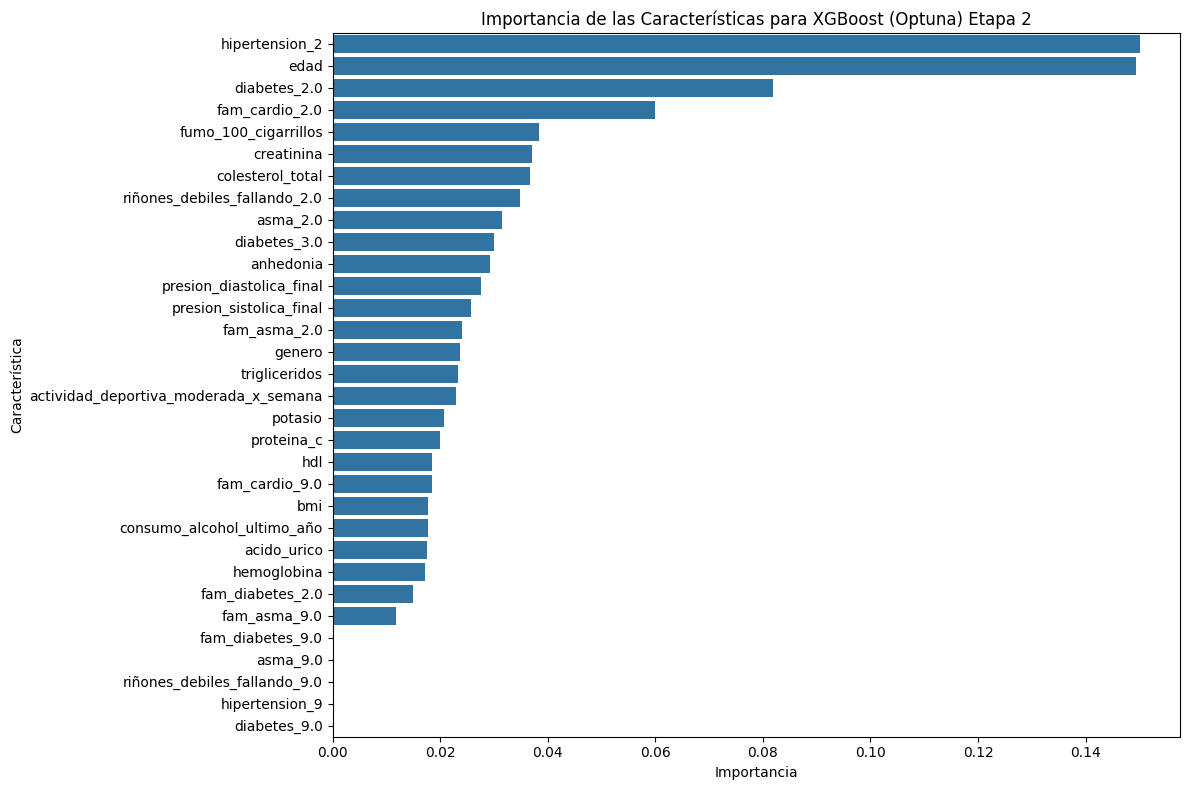

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las importancias de las características del modelo XGBoost
feature_importances_xgb_optuna_etapa3_reop = best_xgb_optuna_model_etapa3_reoptimized.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento de la Etapa 2
feature_names_xgb_optuna_etapa3_reop = X_train_etapa_3.columns

# Crear un DataFrame para visualizar las importancias
importance_df_xgb_optuna_etapa3 = pd.DataFrame({
    'Feature': feature_names_xgb_optuna_etapa3_reop,
    'Importance': feature_importances_xgb_optuna_etapa3_reop
})

# Ordenar por importancia de forma descendente
importance_df_xgb_optuna_etapa3 = importance_df_xgb_optuna_etapa3.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb_optuna_etapa3)
plt.title('Importancia de las Características para XGBoost (Optuna) Etapa 2')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

### Búsqueda de hiperparámetros con Optuna para Random Forest (Undersampling) - Etapa 2

In [ ]:
import optuna
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

def f1_with_threshold_safe(y_true, y_probs):
    try:
        if y_probs.ndim == 2:
            probs_positiva = y_probs[:, 1]
        else:
            probs_positiva = y_probs

        pred_custom = (probs_positiva >= 0.6).astype(int)

        return f1_score(y_true, pred_custom, zero_division=0)
    except Exception:
        return 0.0

custom_f1_scorer = make_scorer(f1_with_threshold_safe, response_method='predict_proba')

def objective_rf_undersampling_etapa3(trial):
    # Hiperparámetros
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=1
    )

    # Pipeline
    pipeline = Pipeline([
        ('undersampler', RandomUnderSampler(sampling_strategy=0.8, random_state=42)),
        ('classifier', model)
    ])

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    try:
        scores = cross_val_score(
            pipeline,
            X_train_etapa_3,
            y_train,
            cv=cv_strategy,
            scoring=custom_f1_scorer,
            n_jobs=-1
        )

        res = np.mean(scores)
        return res if not np.isnan(res) else 0.0
    except Exception:
        return 0.0

study_rf_undersampling_etapa3 = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.INFO)

study_rf_undersampling_etapa3.optimize(objective_rf_undersampling_etapa3, n_trials=50)

print("\n--- Resultados Finales Undersampling Etapa 3 ---")
if len(study_rf_undersampling_etapa3.trials) > 0:
    print(f"Mejores parámetros: {study_rf_undersampling_etapa3.best_params}")
    print(f"Mejor F1-score promedio (CV): {study_rf_undersampling_etapa3.best_value:.4f}")
else:
    print("El estudio no pudo completar ningún trial. Revisá la consistencia de X_train_etapa_3.")

[I 2026-04-22 03:31:21,705] A new study created in memory with name: no-name-865c7d84-2c0c-41a5-b6b9-e1bb45877bc3
[I 2026-04-22 03:31:23,355] Trial 0 finished with value: 0.44597752579017164 and parameters: {'max_depth': 4, 'n_estimators': 150, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.44597752579017164.
[I 2026-04-22 03:31:25,848] Trial 1 finished with value: 0.4826241007492399 and parameters: {'max_depth': 10, 'n_estimators': 200, 'min_samples_split': 19, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.4826241007492399.
[I 2026-04-22 03:31:27,206] Trial 2 finished with value: 0.46946765222548537 and parameters: {'max_depth': 8, 'n_estimators': 100, 'min_samples_split': 14, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.4826241007492399.
[I 2026-04-22 03:31:28,021] Trial 3 finished with value: 0.47094653855236157 and parameters: {'max_depth': 7, 'n_estimators': 50, 'min_samples_split': 11, 'min_samples_leaf': 9}. Best is trial 1 with va


--- Resultados Finales Undersampling Etapa 3 ---
Mejores parámetros: {'max_depth': 9, 'n_estimators': 300, 'min_samples_split': 12, 'min_samples_leaf': 1}
Mejor F1-score promedio (CV): 0.4948


### Evaluación del mejor modelo Random Forest (Undersampling) encontrado por Optuna - Etapa 2


===== Random Forest (Optuna - Under) Re-optimizado Etapa 2 ====
---- TRAIN (Full) ----
AUC: 0.9831
Recall: 0.8029
Precision: 0.9801
F1: 0.8827

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8522
Recall: 0.5732
Precision: 0.7960
F1: 0.6655

---- GAP (Train - CV) ----
AUC gap: 0.1308
Recall gap: 0.2297


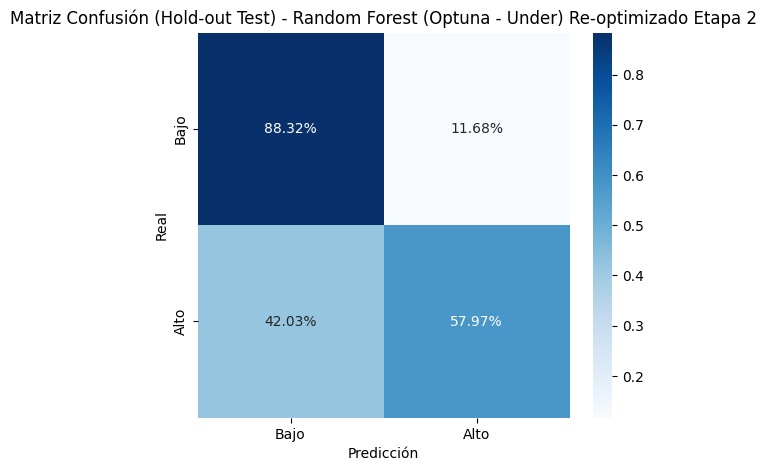

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079
7,XGBoost (Optuna) Etapa 2,0.879030,0.858951,0.316667,0.462737,0.855762,0.813776,0.303959,0.442534,0.023267,0.045176
8,Random Forest Optuna - Under Etapa 2,0.970774,0.896926,0.880995,0.888889,0.850504,0.761310,0.728473,0.744336,0.120270,0.135615
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.877349,0.632911,0.441919,0.520446,0.847210,0.551597,0.414884,0.473144,0.030139,0.081314


In [ ]:
# Obtener el mejor modelo de Optuna para la Etapa 2
best_rf_undersampling_optuna_model_etapa3_reoptimized = RandomForestClassifier(
    **study_rf_undersampling_etapa3.best_params,
    random_state=42
)

undersampler_final_etapa3_reoptimized = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)
X_train_under_final_etapa3_reoptimized, y_train_under_final_etapa3_reoptimized = undersampler_final_etapa3_reoptimized.fit_resample(X_train_etapa_3, y_train)

best_rf_undersampling_optuna_model_etapa3_reoptimized.fit(X_train_under_final_etapa3_reoptimized, y_train_under_final_etapa3_reoptimized)

best_rf_undersampling_optuna_metrics_etapa3_reoptimized = evaluar_overfitting(
    best_rf_undersampling_optuna_model_etapa3_reoptimized,
    X_train_under_final_etapa3_reoptimized, y_train_under_final_etapa3_reoptimized,
    X_test_etapa_3, y_test,
    threshold=0.6,
    nombre="Random Forest (Optuna - Under) Re-optimizado Etapa 2"
)

results.append({"Modelo": "Random Forest (Optuna - Under) Re-optimizado Etapa 2", **best_rf_undersampling_optuna_metrics_etapa3_reoptimized})

# Mostrar los resultados finales actualizados
df_results = pd.DataFrame(results)
display(df_results)

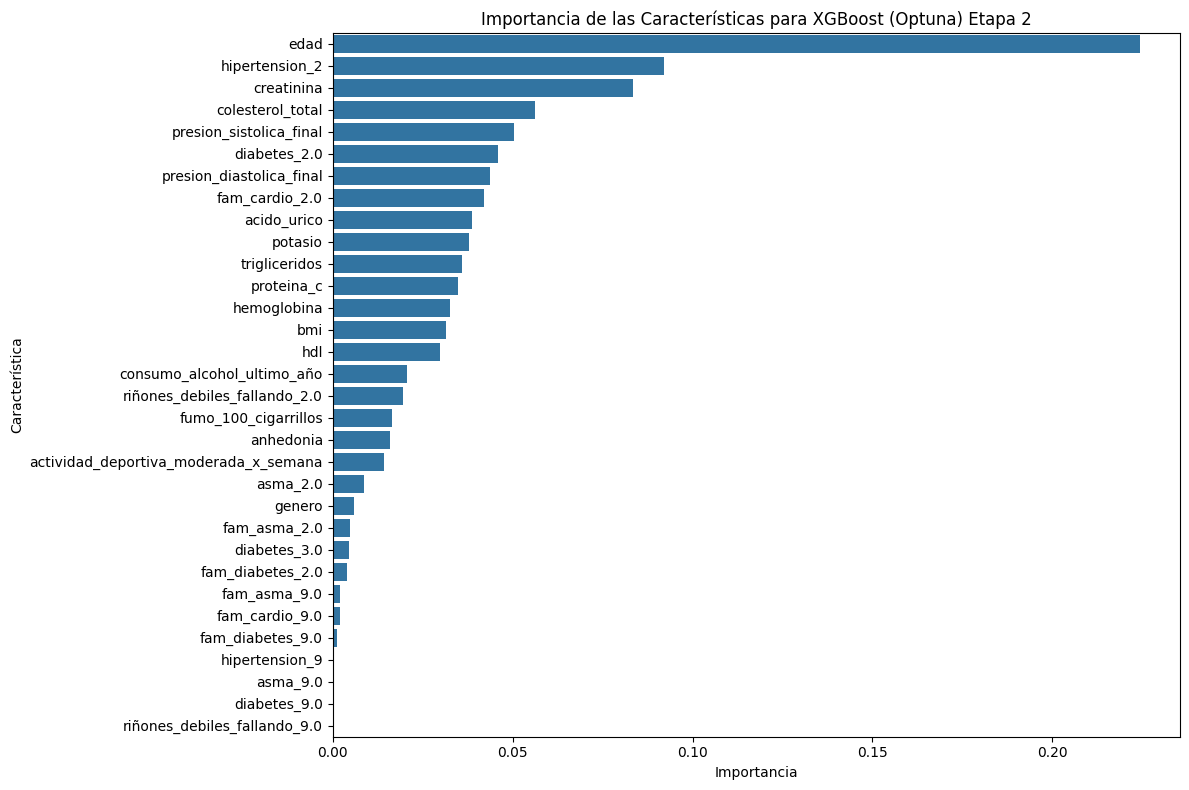

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las importancias de las características del modelo XGBoost
feature_importances_under_optuna_etapa3_reop = best_rf_undersampling_optuna_model_etapa3_reoptimized.feature_importances_

# Obtener los nombres de las características del conjunto de entrenamiento de la Etapa 2
feature_names_under_optuna_etapa3_reop = X_train_under_final_etapa3_reoptimized.columns

# Crear un DataFrame para visualizar las importancias
importance_df_under_optuna_etapa3 = pd.DataFrame({
    'Feature': feature_names_under_optuna_etapa3_reop,
    'Importance': feature_importances_under_optuna_etapa3_reop
})

# Ordenar por importancia de forma descendente
importance_df_under_optuna_etapa3 = importance_df_under_optuna_etapa3.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_under_optuna_etapa3)
plt.title('Importancia de las Características para XGBoost (Optuna) Etapa 2')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

In [ ]:
display(df_results)

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079
7,XGBoost (Optuna) Etapa 2,0.879030,0.858951,0.316667,0.462737,0.855762,0.813776,0.303959,0.442534,0.023267,0.045176
8,Random Forest Optuna - Under Etapa 2,0.970774,0.896926,0.880995,0.888889,0.850504,0.761310,0.728473,0.744336,0.120270,0.135615
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.877349,0.632911,0.441919,0.520446,0.847210,0.551597,0.414884,0.473144,0.030139,0.081314


LOS RESULTADOS QUE SE MUESTRAN A CONTINUACIÓN ESTÁN AGRUPADOS POR MODELO Y SIGUEN EL SIGUIENTE ORDEN:
1. ETAPA 1 BÁSICA (LA MISMA QUE SE UTILIZÓ PARA ANALIZAR LOS MODELOS CON LOS CUALES SE IBA A CONTINUAR PROBANDO).
2. ETAPA 1 OPTIMIZADA
3. ETAPA 2 UTILIZANDO HIPERPARÁMETROS DE ETAPA 1
4. ETAPA 2 CON BUSQUEDA DE HIPERPARÁMETROS PARA ESTA ETAPA

TODOS OPTIMIZADOS CON UMBRAL FIJO DE 0.4 Y UTILIZANDO RECALL COMO MÉTRICA A OPTIMIZAR

### **RAMDOM FOREST BP**

In [ ]:
display(df_results.iloc[[0, 3, 6, 9]])

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.833635,0.329993,0.472821,0.845405,0.766781,0.312052,0.443526,0.039153,0.066853
3,Random Forest - BP Optuna,0.856459,0.813743,0.290323,0.427960,0.842288,0.793923,0.283739,0.418022,0.014170,0.019820
6,Random Forest - BP Optuna Etapa 2,0.863704,0.802893,0.303279,0.440258,0.844145,0.766814,0.294254,0.425247,0.019560,0.036079
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.877349,0.632911,0.441919,0.520446,0.847210,0.551597,0.414884,0.473144,0.030139,0.081314


### **XGBOOST**

In [ ]:
display(df_results.iloc[[1, 4, 7, 10]])

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
1,XGBoost - BP,0.874670,0.851718,0.312127,0.456838,0.855138,0.817396,0.300299,0.439172,0.019532,0.034322
4,XGBoost (Optuna),0.870931,0.851718,0.301151,0.444969,0.853374,0.820999,0.292346,0.431103,0.017557,0.030719
7,XGBoost (Optuna) Etapa 2,0.879030,0.858951,0.316667,0.462737,0.855762,0.813776,0.303959,0.442534,0.023267,0.045176
10,XGBoost (Optuna) Re-optimizado Etapa 2,0.928584,0.815552,0.465909,0.593031,0.854205,0.658296,0.399910,0.497206,0.074378,0.157255


### **RAMDOM FORREST UNDER**

In [ ]:
display(df_results.iloc[[2, 5, 8, 11]])

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
2,Random Forest (Undersampling),0.902240,0.792043,0.779359,0.785650,0.850568,0.759525,0.731700,0.745334,0.051672,0.032518
5,Random Forest (Optuna - Under),0.952993,0.884268,0.833049,0.857895,0.848777,0.779427,0.730781,0.754099,0.104216,0.104841
8,Random Forest Optuna - Under Etapa 2,0.970774,0.896926,0.880995,0.888889,0.850504,0.761310,0.728473,0.744336,0.120270,0.135615
11,Random Forest (Optuna - Under) Re-optimizado E...,0.983063,0.802893,0.980132,0.882704,0.852222,0.573202,0.795983,0.665476,0.130841,0.229691
